# Joint analysis of GRB 130427A with GBM, LLE and LAT data

In [1]:
import warnings

warnings.simplefilter("ignore")
from threeML import *
from threeML.utils.data_download.Fermi_LAT.download_LAT_data import LAT_dataset
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.io import fits

%matplotlib inline

In [2]:
gbm_catalog = FermiGBMBurstCatalog()
source_name = "GRB130427324"
gbm_catalog.query_sources(source_name)
grb_info = gbm_catalog.get_detector_information()[source_name]
grb_info

{'source': {'fluence': '4.096000-142.338000', 'peak': '8.192000-9.216000'},
 'background': {'pre': '-285.420000--41.670000',
  'post': '381.250000-500.000000',
  'full': '-285.420000--41.670000,381.250000-500.000000'},
 'trigger': 'bn130427324',
 'detectors': array(['n6', 'n9', 'na', 'b1'], dtype='<U2'),
 'best fit model': {'fluence': 'band', 'peak': 'band'},
 'ra': 173.136,
 'dec': 27.7129}

In [3]:
trigger_name = "bn130427324"
met = 388741629.420
ra = 173.136
dec = 27.7129
tstart = 0
tstop = 100
gbm_detectors = ["n6", "n9", "b1"]
roi = 10
zmax = 100.0
thetamax = 180.0
irf = "p8_transient010e"

## Prepare GBM data

In [4]:
dload = download_GBM_trigger_data(trigger_name, detectors=gbm_detectors)

In [5]:
bkg_selection = ["-285--41", "310-355"]
gbm_plugins = []
time_series = {}
for det in gbm_detectors:

    # Use CSPEC data to fit the background using the background selections.
    # We use CSPEC because it has a longer duration for fitting the background.

    ts_cspec = TimeSeriesBuilder.from_gbm_cspec_or_ctime(
        det, cspec_or_ctime_file=dload[det]["cspec"], rsp_file=dload[det]["rsp"]
    )

    ts_cspec.set_background_interval(*bkg_selection)
    # The background is saved to an HDF5 file that stores the polynomial coefficients and selections
    ts_cspec.save_background(f"{det}_bkg.h5", overwrite=True)

    # We use TTE data for the actual spectral analysis
    ts_tte = TimeSeriesBuilder.from_gbm_tte(
        det,
        tte_file=dload[det]["tte"],
        rsp_file=dload[det]["rsp"],
        restore_background=f"{det}_bkg.h5",
    )

    time_series[det] = ts_tte

    # The source selection from the catalog is set
    ts_tte.set_active_time_interval("%f-%f" % (tstart, tstop))

    # The plugin for the time integrated analysis is created for each detector
    fluence_plugin = ts_tte.to_spectrumlike()

    # GBM channel selections for spectral analysis
    if det.startswith("b"):
        fluence_plugin.set_active_measurements("900-30000")

    else:
        fluence_plugin.set_active_measurements("40-900")

    fluence_plugin.rebin_on_background(1.0)

    gbm_plugins.append(fluence_plugin)

The default choice for MATRIX extension failed:KeyError("Extension ('MATRIX', 1) not found.")available: None 'EBOUNDS' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX'


No TLMIN keyword found. This DRM does not follow OGIP standards. Assuming TLMIN=1



WARNING RuntimeWarning: invalid value encountered in divide



Loading PHAII Spectra:   0%|          | 0/2182 [00:00<?, ?it/s]


WARNING RuntimeWarning: invalid value encountered in divide



...

No TLMIN keyword found. This DRM does not follow OGIP standards. Assuming TLMIN=1


The default choice for MATRIX extension failed:KeyError("Extension ('MATRIX', 9) not found.")available: None 'EBOUNDS' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX'


No TLMIN keyword found. This DRM does not follow OGIP standards. Assuming TLMIN=1


The default choice for MATRIX extension failed:KeyError("Extension ('MATRIX', 10) not found.")available: None 'EBOUNDS' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX'


No TLMIN keyword found. This DRM does not follow OGIP standards. Assuming TLMIN=1


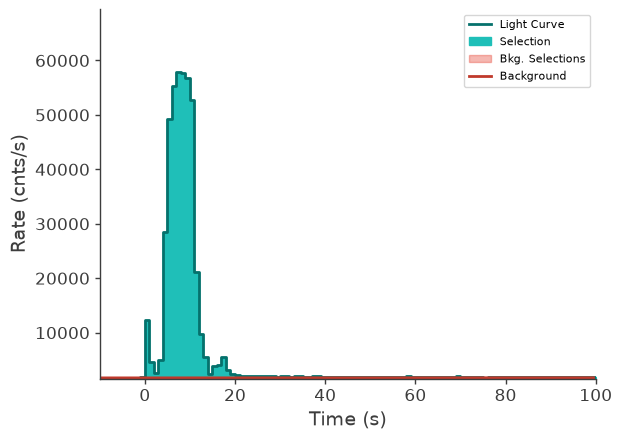

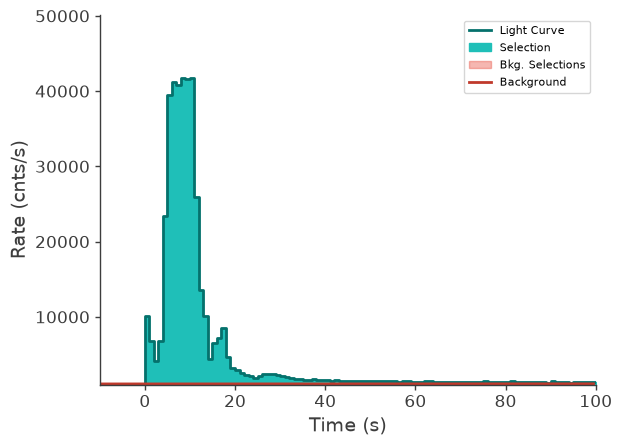

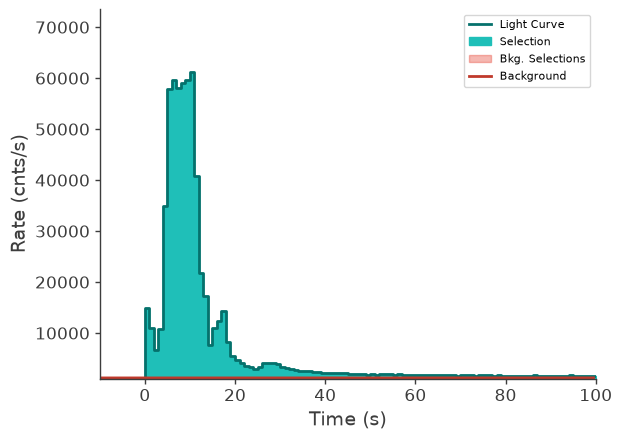

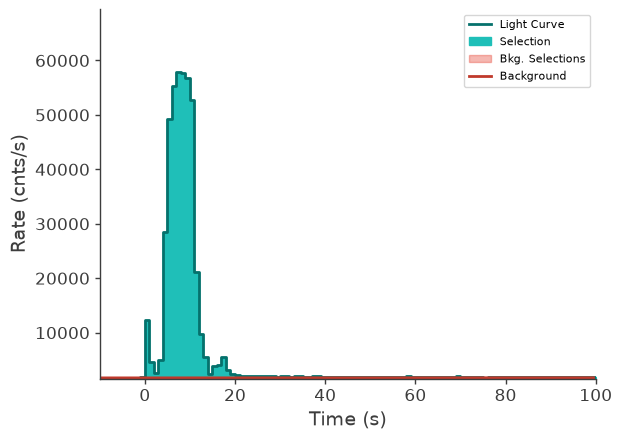

In [6]:
time_series["n6"].view_lightcurve(-10, 100)
time_series["n9"].view_lightcurve(-10, 100)
time_series["b1"].view_lightcurve(-10, 100)

## Prepare LLE data

In [7]:
lle_dload = download_LLE_trigger_data(trigger_name)

In [8]:
bkg_selection = ["-285--41", "400-500"]
emin, emax = 30 * u.MeV, 100 * u.MeV
lle_time_series = TimeSeriesBuilder.from_lat_lle(
    "lat_lle",
    lle_file=lle_dload["lle"],
    ft2_file=lle_dload["ft2"],
    rsp_file=lle_dload["rsp"],
)
lle_time_series.set_background_interval(*bkg_selection)
lle_time_series.save_background("lle_bkg.h5", overwrite=True)

lle_time_series.set_active_time_interval("%d-%d" % (tstart, tstop))

lle_plugin = lle_time_series.to_spectrumlike()
lle_plugin.set_active_measurements(
    "%d-%d" % (emin.to("keV").value, emax.to("keV").value)
)
lle_plugin.use_effective_area_correction(0.8, 1.2)

The default choice for MATRIX extension failed:KeyError("Extension ('MATRIX', 1) not found.")available: None 'EBOUNDS' 'SPECRESP MATRIX'


Finding best polynomial Order:   0%|          | 0/4 [00:00<?, ?it/s]

Fitting GLAST_LLE background:   0%|          | 0/50 [00:00<?, ?it/s]

The current value of parameter a is very close to its lower bound when starting the fit. Fixing it


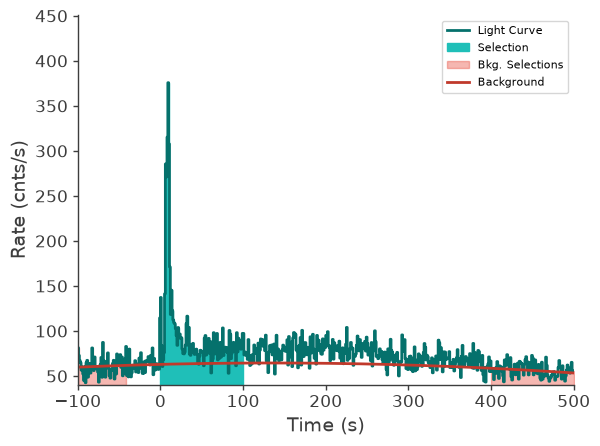

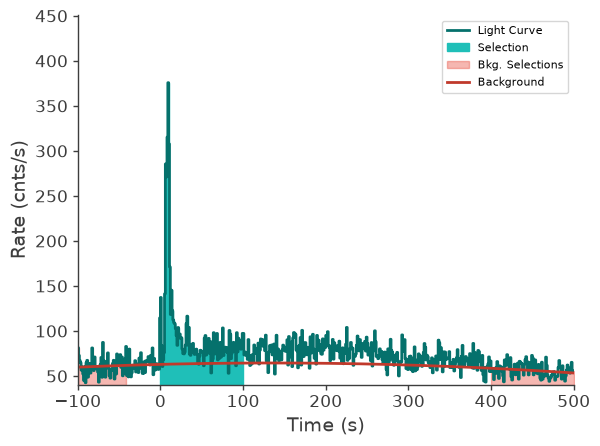

In [9]:
lle_time_series.view_lightcurve(-100, 500)

## Prepare LAT data

In [10]:
LATdataset = LAT_dataset()

LATdataset.make_LAT_dataset(
    ra=ra,
    dec=dec,
    radius=12,
    trigger_time=met,
    tstart=0,
    tstop=1000,
    data_type="Extended",
    destination_directory=".",
    Emin=100.0,  # 100 MeV
    Emax=100000.0,  # 100 GeV
)

Only one FT1 file provided. Skipping the merge...


Writing ./bn130427324/gll_cspec_tr_bn130427324_v00.rsp...
time -p gtselect infile=./bn130427324/gll_ft1_tr_bn130427324_v00.fit outfile=__temp_ft1.fits ra=173.136 dec=27.7129 rad=15.0 tmin=388741628.42 tmax=388742630.42 emin=10.0 emax=1000000.0 zmin=0.0 zmax=110.0 evclass="INDEF" evtype="INDEF" convtype=-1 phasemin=0.0 phasemax=1.0 evtable="EVENTS" chatter=2 clobber=yes debug=no gui=no mode="ql"
Done.
real 0.05
user 0.04
sys 0.01
Writing ./bn130427324/gll_cspec_tr_bn130427324_v00.pha...
 *  Get energy binning from the response matrix...

    done.

 *  Run gtbindef and gtbin and bin in energy and time...

time -p gtbindef bintype="E" binfile=__ebins.txt outfile=__energyBins.fits energyunits="keV" chatter=2 clobber=yes debug=no gui=no mode="ql"
This is gtbindef version HEAD
real 0.01
user 0.00
sys 0.00
time -p gtbin evfile=/home/runner/work/threeML/threeML/docs/md_docs/slow_execute/__temp_ft1.fits scfile=/home/runner/work/threeML/threeML/docs/md_docs/slow_execute/bn130427324/gll_ft2_tr_b

real 1.88
user 1.80
sys 0.07

    done.

 *  Transform gtbin output in CSPEC format...

    done.

 *  Updating keywords in the headers of the CSPEC file...

    done.

gtllebin done!


time -p gtmktime scfile=/home/runner/work/threeML/threeML/docs/md_docs/slow_execute/bn130427324/gll_ft2_tr_bn130427324_v00.fit sctable="SC_DATA" filter="(DATA_QUAL>0 || DATA_QUAL==-1) && LAT_CONFIG==1 && IN_SAA!=T && LIVETIME>0 && (ANGSEP(RA_ZENITH,DEC_ZENITH,173.136,27.7129)<=(100.0-10))" roicut=no evfile=/home/runner/work/threeML/threeML/docs/md_docs/slow_execute/bn130427324/gll_ft1_tr_bn130427324_v00.fit evtable="EVENTS" outfile="gll_ft1_tr_bn130427324_v00_mkt.fit" apply_filter=yes overwrite=no header_obstimes=yes tstart=388741629.42 tstop=388742629.42 gtifile="default" chatter=2 clobber=yes debug=no gui=no mode="ql"
real 0.04
user 0.02
sys 0.01

Using 305 data

time -p gtselect infile=gll_ft1_tr_bn130427324_v00_mkt.fit outfile=gll_ft1_tr_bn130427324_v00_filt.fit ra=173.136 dec=27.7129 rad=10.0 tmin=388741629.42 tmax=388742629.42 emin=100.0 emax=100000.0 zmin=0.0 zmax=100.0 evclass=32 evtype=3 convtype=-1 phasemin=0.0 phasemax=1.0 evtable="EVENTS" chatter=2 clobber=yes debug=no gui=

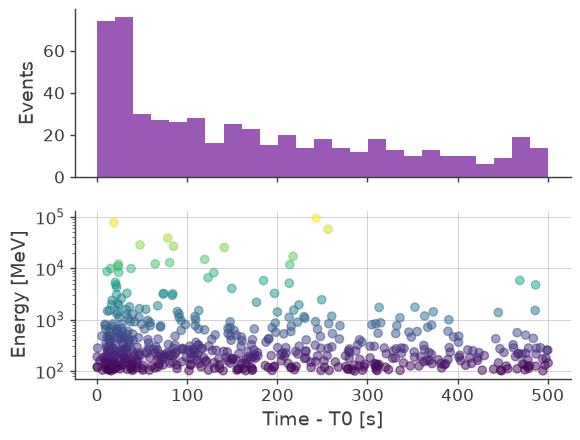

In [11]:
LATdataset.extract_events(roi, zmax, irf)

with fits.open(LATdataset.filt_file) as event_file:
    lat_events = event_file["EVENTS"].data
event_times = lat_events["TIME"] - met

%matplotlib inline
fig, axs = plt.subplots(2, 1, sharex=True)
plt.sca(axs[0])
plt.hist(event_times)
plt.ylabel("Events")
plt.sca(axs[1])
plt.scatter(
    event_times,
    lat_events["ENERGY"],
    marker="o",
    c=lat_events["ENERGY"],
    norm="log",
    alpha=0.5,
    zorder=20,
)
plt.yscale("log")
plt.ylabel("Energy [MeV]")
plt.xlabel("Time - T0 [s]")
plt.grid(True)
plt.show()

In [12]:
analysis_builder = TransientLATDataBuilder(
    LATdataset.grb_name,
    outfile=LATdataset.grb_name,
    roi=roi,
    tstarts="%d" % tstart,
    tstops="%d" % tstop,
    irf=irf,
    zmax=zmax,
    galactic_model="template",
    particle_model="isotr template",
    datarepository=".",
)
df = analysis_builder.display(get=True)

outfile                      130427324
roi                                 10
tstarts                              0
tstops                             100
zmax                             100.0
emin                             100.0
emax                          100000.0
irf                   p8_transient010e
galactic_model                template
particle_model          isotr template
source_model                 PowerLaw2
tsmin                             20.0
strategy                          time
thetamax                         180.0
spectralfiles                       no
liketype                      unbinned
optimizeposition                    no
datarepository                       .
ltcube                                
expomap                               
ulphindex                           -2
flemin                             100
flemax                           10000
fgl_mode                          fast
filter_GTI                       False
likelihood_profile       

In [13]:
LAT_observations = analysis_builder.run(recompute_intervals=True)
LAT_plugin = LAT_observations[0].to_LATLike()

100  196605
107.227  211690
114.976  226222
123.285  241159
132.194  256370
141.747  269989
151.991  282530
162.975  295087
174.753  305943
187.382  316292
200.923  325964
215.443  335190
231.013  343788
247.708  351441
265.609  359019
284.804  366947
305.386  375002
327.455  382834
351.119  391370
376.494  400323
403.702  409223
432.876  417810
464.159  425931
497.702  433805
533.67  440988
572.237  448804
613.591  455198
657.933  465129
705.48  474585
756.463  481309
811.131  488095
869.749  496634
932.603  505178
1000  511275
1072.27  519318
1149.76  523766
1232.85  528106
1321.94  528495
1417.47  528428
1519.91  529135
1629.75  529964
1747.53  532895
1873.82  535996
2009.23  536440
2154.43  535680
2310.13  536962
2477.08  539306
2656.09  538555
2848.04  535688
3053.86  534663
3274.55  536370
3511.19  534105
3764.94  528587
4037.02  523435
4328.76  518817
4641.59  516826
4977.02  519861
5336.7  522287
5722.37  521166
6135.91  521663
6579.33  520838
7054.8  520074
7564.63  519641
811

 **********
 **    1 **SET PRINT     .000    
 **********
 **********
 **    2 **SET NOWARN 
 **********

 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 'Integral  '    .10000E-01   1.0000         .10000E-04   1000.0    
     2 'Index     '   -2.0000       1.0000        -6.0000       .10000E-01
     3 'Value     '    1.0000       1.0000         .70000       1.3000    
     4 'Normalizat'    1.0000       1.0000         .10000       10.000    
 **********
 **    3 **SET ERR    .5000    
 **********
 **********
 **    4 **SET GRAD    1.000    
 **********
 **********
 **    5 **MINIMIZE    600.0       2.000    
 **********

 MIGRAD MINIMIZATION HAS CONVERGED.

 MIGRAD WILL VERIFY CONVERGENCE AND ERROR MATRIX.

 FCN=   771.6132     FROM MIGRAD    STATUS=CONVERGED     73 CALLS       74 TOTAL
                     EDM=   .65E-05    STRATEGY= 1      ERROR MATRIX ACCURATE 

  EXT PARAMETER                                   STEP         FIRST   
  NO.   NA


Requested intervals:
------------------------------------------------------
0.0                  - 100.0

Data files:
-----------
eventfile            /home/runner/work/threeML/threeML/docs/md_docs/slow_execute/bn130427324/gll_ft1_tr_bn130427324_v00.fit
ft2file              /home/runner/work/threeML/threeML/docs/md_docs/slow_execute/bn130427324/gll_ft2_tr_bn130427324_v00.fit
rspfile              /home/runner/work/threeML/threeML/docs/md_docs/slow_execute/bn130427324/gll_cspec_tr_bn130427324_v00.rsp
cspecfile            /home/runner/work/threeML/threeML/docs/md_docs/slow_execute/bn130427324/gll_cspec_tr_bn130427324_v00.pha

ROI:
-----
R.A.                 173.136
Dec.                 27.7129
Radius               10.0

Interval # 1 (0.0-100.0):
-----------------------

-> gtdocountsmap.py rad='10.0' eventfile='/home/runner/work/threeML/threeML/docs/md_docs/slow_execute/bn130427324/gll_ft1_tr_bn130427324_v00.fit' zmax='100.0' thetamax='180.0' emin='100.0' emax='100000.0' skymap='13042732



Log(likelihood) = 771.6131616797278
time -p gtsrcprob evfile=/home/runner/work/threeML/threeML/docs/md_docs/slow_execute/interval0.0-100.0/gll_ft1_tr_bn130427324_v00_filt.fit evtable="EVENTS" scfile=/home/runner/work/threeML/threeML/docs/md_docs/slow_execute/bn130427324/gll_ft2_tr_bn130427324_v00.fit sctable="SC_DATA" outfile=/home/runner/work/threeML/threeML/docs/md_docs/slow_execute/interval0.0-100.0/gll_ft1_tr_bn130427324_v00_filt_prob.fit srcmdl=gll_ft1_tr_bn130427324_v00_filt_likeRes.xml irfs="CALDB" evtype="INDEF" srclist= chatter=2 clobber=yes debug=no gui=no mode="ql"
real 3.58
user 3.13
sys 0.45



FermiLATLike - GTI SUM =  100.0


## Define the first model to test

In [14]:
band = Band()
band.alpha.prior = Truncated_gaussian(lower_bound=-1.5, upper_bound=1, mu=-1, sigma=0.5)
band.beta.prior = Truncated_gaussian(lower_bound=-5, upper_bound=-1.6, mu=-2, sigma=0.5)
band.xp.prior = Log_normal(mu=2, sigma=1)
band.xp.bounds = (None, None)
band.K.prior = Log_uniform_prior(lower_bound=1e-10, upper_bound=1e3)
source = PointSource(trigger_name, ra, dec, spectral_shape=band)
band_model = Model(source)

We have set the min_value of Band.xp to 1e-99 because there was a postive transform


We have set the min_value of Band.xp to 1e-99 because there was a postive transform


## Run the joint fit

In [15]:
datalist_1 = DataList(*gbm_plugins, lle_plugin, LAT_plugin)
jl_1 = JointLikelihood(band_model, datalist_1, verbose=False)
band_model.display()
print(jl_1.data_list.keys())
# This is needed to fix the galactic template to 1 (if needed)
band_model[LAT_plugin.get_name() + "_GalacticTemplate_Value"].value = 1.0
band_model[LAT_plugin.get_name() + "_GalacticTemplate_Value"].fix = True
band_model[LAT_plugin.get_name() + "_IsotropicTemplate_Normalization"].fix = False
# sbpl_model.display(complete=True)
jl_1.set_minimizer("minuit")
jl_1.fit()


Found Isotropic template for irf P8R3_TRANSIENT010E_V3: /home/runner/miniconda3/envs/test_env/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_TRANSIENT010E_V3_v1.txt

Found Galactic template for IRF. P8R3_TRANSIENT010E_V3: /home/runner/miniconda3/envs/test_env/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 

100  196605
107.227  211690
114.976  226222
123.285  241159
132.194  256370
141.747  269989
151.991  282530
162.975  295087
174.753  305943
187.382  316292
200.923  325964
215.443  335190
231.013  343788
247.708  351441
265.609  359019
284.804  366947
305.386  375002
327.455  382834
351.119  391370
376.494  400323
403.702  409223
432.876  417810
464.159  425931
497.702  433805
533.67  440988
572.237  448804
613.591  455198
657.933  465129
705.48  474585
756.463  481309
811.131  488095
869.749  496634
932.603  505178
1000  511275
1072.27  519318
1149.76  523766
1232.85  528106
1321.94  528495
1417.47  528428
1519.91  529135
1629.

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (7):
--------------------

                                           value min_value max_value  \
bn130427324.spectrum.main.Band.K          0.0001       0.0      None   
bn130427324.spectrum.main.Band.alpha        -1.0      -1.5       3.0   
bn130427324.spectrum.main.Band.xp          500.0       0.0      None   
bn130427324.spectrum.main.Band.beta         -2.0      -5.0      -1.6   
cons_lat_lle                                 1.0       0.8       1.2   
LAT0X100_GalacticTemplate_Value              1.0       0.5       1.5   
LAT0X100_IsotropicTemplate_Normalization     1.0       0.1       5.0   

                                                    unit  
bn130427324.spectrum.main.Band.K          keV-1 s-1 cm-2  
bn130427324.spectrum.main.Band.alpha                      
bn130427324.spectrum.main.Band.xp                    keV  
bn130427324.spectrum.main.Band.beta                       
cons_lat_lle                                              
LAT0X100_GalacticTemplate_Value                           
LAT0X100_IsotropicTemplate_Normalization                  

Fixed parameters (6):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

odict_keys(['n6', 'n9', 'b1', 'lat_lle', 'LAT0X100'])


Best fit values:

,result,unit
parameter,,
bn130427324.spectrum.main.Band.K,(1.496 +/- 0.004) x 10^-1,1 / (keV s cm2)
bn130427324.spectrum.main.Band.alpha,(-9.12 +/- 0.05) x 10^-1,
bn130427324.spectrum.main.Band.xp,(7.76 +/- 0.07) x 10^2,keV
bn130427324.spectrum.main.Band.beta,-2.837 +/- 0.011,
cons_lat_lle,(8.0000 +/- 0.0005) x 10^-1,
LAT0X100_IsotropicTemplate_Normalization,5.000 +/- 0.018,


...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
n6,1109.980737
n9,1063.105234
b1,896.397975
lat_lle,85.188072
LAT0X100,1913.535496
total,5068.207514


Values of statistical measures:

,statistical measures
AIC,10148.573519
BIC,10174.131017


(                                               value  negative_error  \
 bn130427324.spectrum.main.Band.K            0.149628       -0.000429   
 bn130427324.spectrum.main.Band.alpha       -0.912123       -0.004771   
 bn130427324.spectrum.main.Band.xp         775.990217       -6.748309   
 bn130427324.spectrum.main.Band.beta        -2.837093       -0.009957   
 cons_lat_lle                                0.800000        0.000011   
 LAT0X100_IsotropicTemplate_Normalization    4.999963       -0.025272   
 
                                           positive_error     error  \
 bn130427324.spectrum.main.Band.K                0.000408  0.000419   
 bn130427324.spectrum.main.Band.alpha            0.004973  0.004872   
 bn130427324.spectrum.main.Band.xp               6.780128  6.764218   
 bn130427324.spectrum.main.Band.beta             0.010609  0.010283   
 cons_lat_lle                                    0.000070  0.000040   
 LAT0X100_IsotropicTemplate_Normalization       -0.003898  0.

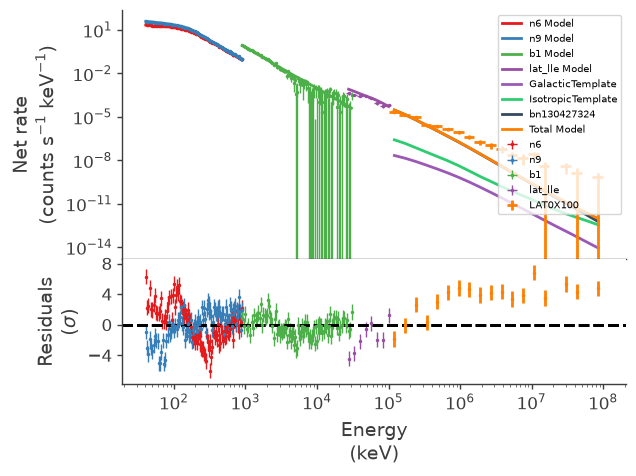

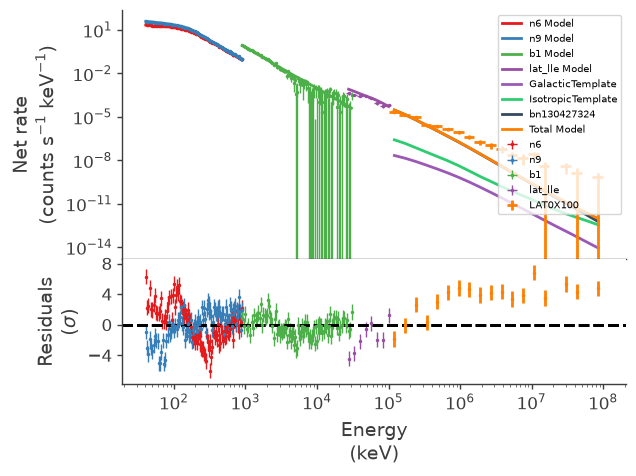

In [16]:
display_spectrum_model_counts(jl_1)

## Define a second model to test

In [17]:
spectrum = Band() + Powerlaw()
# spectrum.K_1 = 0.1
# spectrum.break_energy_1 = 800
# spectrum.beta_1 = -3
# spectrum.K_2 = 3
source_2 = PointSource("%s_2" % trigger_name, ra, dec, spectral_shape=spectrum)
comp_model = Model(source_2)
comp_model.display()

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (6):
--------------------

                          value min_value max_value            unit
bn130427324_2...K_1      0.0001       0.0      None  keV-1 s-1 cm-2
bn130427324_2...alpha_1    -1.0      -1.5       3.0                
bn130427324_2...xp_1      500.0      10.0      None             keV
bn130427324_2...beta_1     -2.0      -5.0      -1.6                
bn130427324_2...K_2         1.0       0.0    1000.0  keV-1 s-1 cm-2
bn130427324_2...index_2   -2.01     -10.0      10.0                

Fixed parameters (4):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

## Run the joint fit again

In [18]:
datalist_2 = DataList(*gbm_plugins, lle_plugin, LAT_plugin)
jl_2 = JointLikelihood(comp_model, datalist_2, verbose=False)
comp_model[LAT_plugin.get_name() + "_GalacticTemplate_Value"].value = 1.0
comp_model[LAT_plugin.get_name() + "_GalacticTemplate_Value"].fix = True
comp_model[LAT_plugin.get_name() + "_IsotropicTemplate_Normalization"].fix = False
jl_2.set_minimizer("minuit")
jl_2.fit()


Found Isotropic template for irf P8R3_TRANSIENT010E_V3: /home/runner/miniconda3/envs/test_env/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_TRANSIENT010E_V3_v1.txt

Found Galactic template for IRF. P8R3_TRANSIENT010E_V3: /home/runner/miniconda3/envs/test_env/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 

100  196605
107.227  211690
114.976  226222
123.285  241159
132.194  256370
141.747  269989


151.991  282530
162.975  295087
174.753  305943
187.382  316292
200.923  325964
215.443  335190
231.013  343788
247.708  351441
265.609  359019
284.804  366947
305.386  375002
327.455  382834
351.119  391370
376.494  400323
403.702  409223
432.876  417810
464.159  425931
497.702  433805
533.67  440988
572.237  448804
613.591  455198
657.933  465129
705.48  474585
756.463  481309
811.131  488095
869.749  496634
932.603  505178
1000  511275
1072.27  519318
1149.76  523766
1232.85  528106
1321.94  528495
1417.47  528428
1519.91  529135
1629.75  529964
1747.53  532895
1873.82  535996
2009.23  536440
2154.43  535680
2310.13  536962
2477.08  539306
2656.09  538555
2848.04  535688
3053.86  534663
3274.55  536370
3511.19  534105
3764.94  528587
4037.02  523435
4328.76  518817
4641.59  516826
4977.02  519861
5336.7  522287
5722.37  521166
6135.91  521663
6579.33  520838
7054.8  520074
7564.63  519641
8111.31  518998
8697.49  516277
9326.03  513697
10000  516273
10722.7  518121
11497.6  520112
1

These parameters returned a logLike = Nan: [259.92822995   1.53077367 274.27670349  -3.45154891 -20.59301566
   9.94140937   0.82832308   4.99994496]


These parameters returned a logLike = Nan: [158.75684852  -0.98267879  78.06505196  -1.70764025 -29.02032627
  -1.67528337   0.83122382   4.99987956]


Best fit values:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
n6,1114.957452
n9,1061.462519
b1,879.481269
lat_lle,69.614781
LAT0X100,1811.597130
total,4937.113152


Values of statistical measures:

,statistical measures
AIC,9890.499031
BIC,9924.514289


(                                                    value  negative_error  \
 bn130427324_2.spectrum.main.composite.K_1        0.148030       -0.000565   
 bn130427324_2.spectrum.main.composite.alpha_1   -0.919227       -0.005199   
 bn130427324_2.spectrum.main.composite.xp_1     799.117969       -6.949491   
 bn130427324_2.spectrum.main.composite.beta_1    -3.070594       -0.050567   
 bn130427324_2.spectrum.main.composite.K_2        1.398550       -0.761494   
 bn130427324_2.spectrum.main.composite.index_2   -1.721474       -0.057275   
 cons_lat_lle                                     0.934518       -0.077706   
 LAT0X100_IsotropicTemplate_Normalization         4.999991       -0.015621   
 
                                                positive_error     error  \
 bn130427324_2.spectrum.main.composite.K_1            0.000521  0.000543   
 bn130427324_2.spectrum.main.composite.alpha_1        0.004904  0.005052   
 bn130427324_2.spectrum.main.composite.xp_1           7.565961  7.25

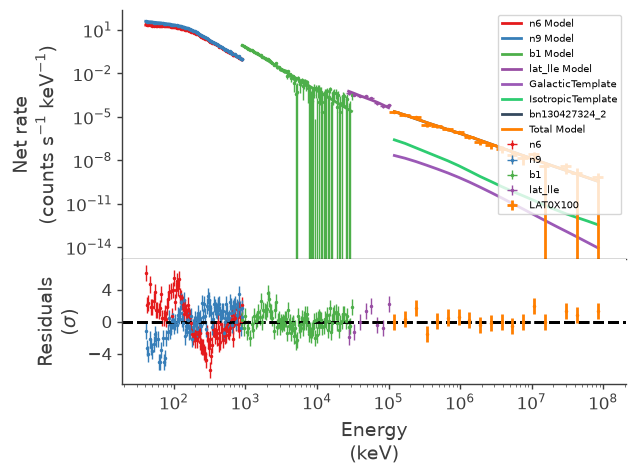

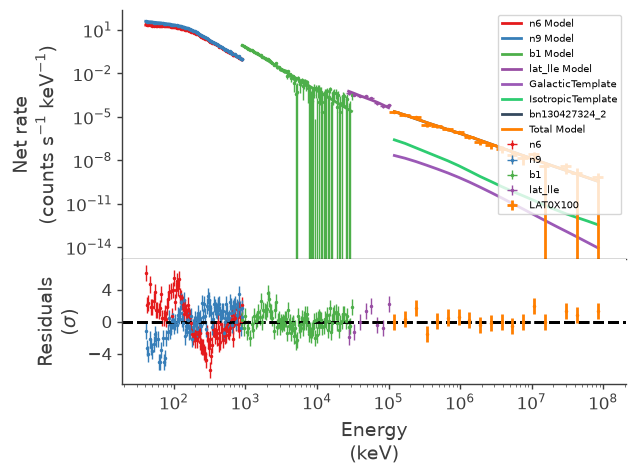

In [19]:
display_spectrum_model_counts(jl_2, show_residuals=True)

In [20]:
jl_1.results.get_statistic_measure_frame()

,statistical measures
AIC,10148.573519
BIC,10174.131017


In [21]:
jl_2.results.get_statistic_measure_frame()

,statistical measures
AIC,9890.499031
BIC,9924.514289


## Plot the two components of the best-fit spectrum

processing MLE analyses:   0%|          | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|          | 0/100 [00:00<?, ?it/s]

Propagating errors:   0%|          | 0/100 [00:00<?, ?it/s]

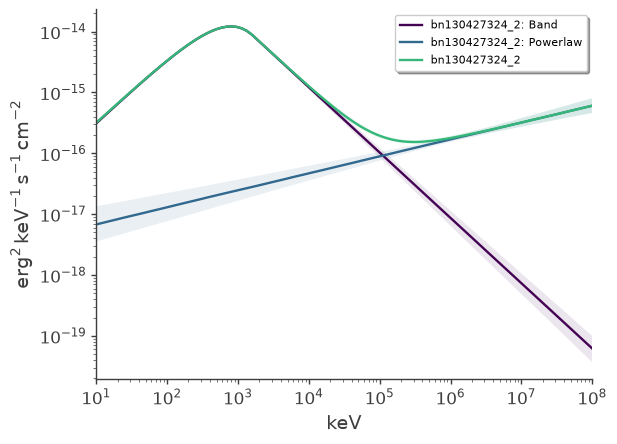

In [22]:
fig = plot_spectra(
    jl_2.results,
    ene_min=10 * u.keV,
    ene_max=100 * u.GeV,
    flux_unit="erg2/(cm2 s keV)",
    fit_cmap="viridis",
    contour_cmap="viridis",
    contour_style_kwargs=dict(alpha=0.1),
    use_components=True,
    components_to_use=["total", "Band", "Powerlaw"],
)

## Compute the flux

In [23]:
jl_2.results.get_flux(
    ene_min=10 * u.keV, ene_max=100 * u.GeV, use_components=True, flux_unit="1/(cm2 s)"
)

processing MLE analyses:   0%|          | 0/1 [00:00<?, ?it/s]

,flux,low bound,hi bound
bn130427324_2: Band,56.25415395851509 1 / (s cm2),56.04575757683044 1 / (s cm2),56.478180948907365 1 / (s cm2)
bn130427324_2: Powerlaw,0.3839611150435297 1 / (s cm2),0.21673765776801832 1 / (s cm2),0.6998164959729332 1 / (s cm2)


In [24]:
jl_2.results.get_flux(
    ene_min=10 * u.keV, ene_max=100 * u.GeV, use_components=False, flux_unit="1/(cm2 s)"
)

processing MLE analyses:   0%|          | 0/1 [00:00<?, ?it/s]

,flux,low bound,hi bound
bn130427324_2: total,56.69982214186797 1 / (s cm2),56.5195140190126 1 / (s cm2),56.89925440727586 1 / (s cm2)
